# Cross-Market Correlation Strategy: BTC & NASDAQ Futures


# 1. Project Understanding

## 1.1 Project Objective and Approach
This project aims to enhance the performance of a systematic trading strategy through the application of machine-learning techniques. A "baseline" rule-based strategy is first evaluated using historical backtesting to establish benchmark performance. Its limitations are then systematically analyzed, after which an appropriate machine-learning model is applied to address the identified weaknesses. The effectiveness of the proposed approach is evaluated by comparing trading performance before and after the integration of machine learning.

## 1.2 Hypothesis Definition
At short intraday time scales, directional agreement between Bitcoin (BTC) and NASDAQ-100 (NQ) futures reflects more stable market conditions, whereas directional divergence indicates increased market uncertainty and reduced trend persistence.


# 2. Data Understanding and Preparation

Goal: Explore, diagnose, and validate the raw data.

## 2.1 Data Sources and Structure
- **Assets:** BTCUSDT Perpetual Futures, NASDAQ-100 E-mini Futures  
- **Interval:** 1-minute OHLCV  
- **Period:** 1 Oct 2025 at 00:00:00 UTC – 12 Dec 2025 at 22:59:00 UTC  
- **Source:** TradingView
- **Columns:** timestamp, open, high, low, close, volume  
- **Market structure:** BTC trades 24/7, NQ trades during CME sessions

## 2.2 Timestamp Handling and Synchronization
0. Read and inspect CSVs

In [3]:
import pandas as pd

# Assuming 'Datasets' folder is in the same directory as the notebook
btc = pd.read_csv("Datasets/btc_raw_data.csv", sep=',')
nq  = pd.read_csv("Datasets/nq_raw_data.csv", sep=',')

# Inspect columns 
print("BTC Columns:", btc.columns)
print("BTC Head:\n", btc.head())
print("Total BTC rows:", len(btc))

print("\nNQ Columns:", nq.columns)
print("NQ Head:\n", nq.head())
print("Total NQ rows:", len(nq))


BTC Columns: Index(['time', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
BTC Head:
          time      open      high       low     close   volume
0  1759276800  113988.7  114045.0  113988.7  114039.0  114.672
1  1759276860  114039.0  114166.6  114038.9  114116.4  332.542
2  1759276920  114116.3  114120.0  114089.7  114112.9   94.812
3  1759276980  114112.9  114116.2  114096.3  114112.3   78.905
4  1759277040  114112.4  114166.8  114090.8  114166.8   92.484
Total BTC rows: 106500

NQ Columns: Index(['time', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
NQ Head:
          time      open      high       low     close  volume
0  1759294800  24774.50  24778.25  24773.75  24777.25      54
1  1759294860  24777.00  24778.25  24775.25  24778.25      31
2  1759294920  24778.25  24780.00  24777.25  24778.25      49
3  1759294980  24778.00  24779.75  24775.25  24775.25      28
4  1759295040  24775.25  24777.00  24774.75  24777.00      11
Total NQ rows: 72255


1. Convert timestamps to datetime
2. Align both assets to the same timezone (UTC+1 / Polish time)
3. Synchronize datasets on common timestamps
4. Prepare the merged DataFrame for further analysis

In [4]:
# Convert UNIX epoch to datetime (assume UTC)
btc['timestamp'] = pd.to_datetime(btc['time'], unit='s', utc=True)
nq['timestamp']  = pd.to_datetime(nq['time'], unit='s', utc=True)

# Optional: convert to local time (Polish time UTC+1)
btc['timestamp'] = btc['timestamp'].dt.tz_convert('Europe/Warsaw')
nq['timestamp']  = nq['timestamp'].dt.tz_convert('Europe/Warsaw')

# Set timestamp as index
btc.set_index('timestamp', inplace=True)
nq.set_index('timestamp', inplace=True)

# Sort by timestamp just in case
btc.sort_index(inplace=True)
nq.sort_index(inplace=True)

# Keep only common timestamps for synchronized analysis
common_index = btc.index.intersection(nq.index)
btc_sync = btc.loc[common_index]
nq_sync  = nq.loc[common_index]

print("BTC synchronized head:\n", btc_sync.head())
print("NQ synchronized head:\n", nq_sync.head())
print("Total synchronized rows:", len(common_index))

print(btc_sync)
print(nq_sync.head)

BTC synchronized head:
                                  time      open      high       low     close  \
timestamp                                                                       
2025-10-01 07:00:00+02:00  1759294800  114227.8  114286.4  114227.8  114270.4   
2025-10-01 07:01:00+02:00  1759294860  114270.5  114305.0  114200.8  114227.7   
2025-10-01 07:02:00+02:00  1759294920  114227.7  114291.2  114213.2  114213.3   
2025-10-01 07:03:00+02:00  1759294980  114213.2  114225.0  114205.2  114220.7   
2025-10-01 07:04:00+02:00  1759295040  114220.6  114266.6  114220.6  114253.8   

                            volume  
timestamp                           
2025-10-01 07:00:00+02:00  136.105  
2025-10-01 07:01:00+02:00  241.234  
2025-10-01 07:02:00+02:00  158.247  
2025-10-01 07:03:00+02:00   53.101  
2025-10-01 07:04:00+02:00  124.601  
NQ synchronized head:
                                  time      open      high       low     close  \
timestamp                                    

## 2.3 Data Quality Checks

In [5]:
import numpy as np
from scipy.stats import zscore

# 1. Check for missing values
print("BTC missing values per column:\n", btc_sync.isna().sum())
print("\nNQ missing values per column:\n", nq_sync.isna().sum())

# 2. Check for duplicated timestamps
print("\nDuplicated BTC timestamps:", btc_sync.index.duplicated().sum())
print("Duplicated NQ timestamps:", nq_sync.index.duplicated().sum())

# 3. Basic descriptive statistics(Close prices)
print("\nBTC descriptive statistics (Close):\n", btc_sync['close'].describe())
print("\nNQ descriptive statistics (Close):\n", nq_sync['close'].describe())

# 4. Outlier detection on log returns

# Compute log returns FIRST (needed for diagnostics)
btc_sync['return'] = np.log(btc_sync['close']).diff()
nq_sync['return']  = np.log(nq_sync['close']).diff()

# Drop NaNs created by diff()
btc_ret = btc_sync['return'].dropna()
nq_ret  = nq_sync['return'].dropna()

# Z-score based outlier check (|z| > 4)
btc_outliers = (np.abs(zscore(btc_ret)) > 4).sum()
nq_outliers  = (np.abs(zscore(nq_ret)) > 4).sum()

print("\nExtreme return outliers (|z| > 4):")
print(f"BTC: {btc_outliers}")
print(f"NQ : {nq_outliers}")


BTC missing values per column:
 time      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

NQ missing values per column:
 time      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Duplicated BTC timestamps: 0
Duplicated NQ timestamps: 0

BTC descriptive statistics (Close):
 count     72255.000000
mean     103208.135719
std       11654.184826
min       80685.600000
25%       91860.200000
50%      104156.200000
75%      111645.350000
max      126086.800000
Name: close, dtype: float64

NQ descriptive statistics (Close):
 count    72255.000000
mean     25332.211131
std        451.056656
min      23910.750000
25%      25051.750000
50%      25313.000000
75%      25665.250000
max      26396.250000
Name: close, dtype: float64

Extreme return outliers (|z| > 4):
BTC: 351
NQ : 534


In [ ]:
#OPTIONAL: Save final datasets
save_final = True  # Set to False if you don't want to save

if save_final:
    btc_final_path = "Datasets/btc_final.csv"
    nq_final_path = "Datasets/nq_final.csv"
    
    # Save synchronized and processed datasets
    btc_sync.to_csv(btc_final_path)
    nq_sync.to_csv(nq_final_path)
    
    print(f"BTC final synchronized dataset saved to {btc_final_path}")
    print(f"NQ final synchronized dataset saved to {nq_final_path}")
    print("Total synchronized rows saved:", len(common_index))

## 2.4 Return Computation

Merged Returns Head:
                            BTC_return  NQ_return
timestamp                                       
2025-10-01 07:01:00+02:00   -0.000374   0.000040
2025-10-01 07:02:00+02:00   -0.000126   0.000000
2025-10-01 07:03:00+02:00    0.000065  -0.000121
2025-10-01 07:04:00+02:00    0.000290   0.000071
2025-10-01 07:05:00+02:00    0.000472  -0.000020
Merged Returns Description:
          BTC_return     NQ_return
count  72254.000000  7.225400e+04
mean      -0.000003  2.355206e-07
std        0.000757  3.256984e-04
min       -0.018519 -5.110953e-03
25%       -0.000355 -1.103537e-04
50%        0.000000  0.000000e+00
75%        0.000346  1.170010e-04
max        0.033086  2.239292e-02
Total rows after dropna: 72254


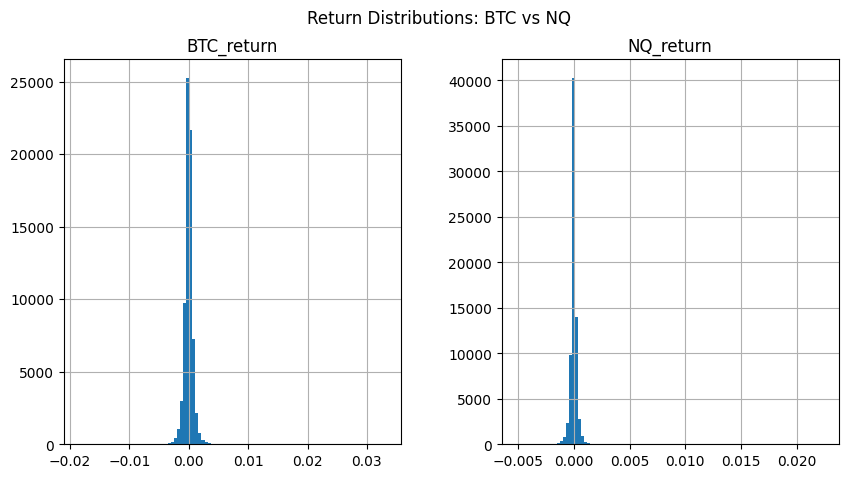

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Compute 1-minute log returns
btc_sync['return'] = np.log(btc_sync['close']).diff()
nq_sync['return']  = np.log(nq_sync['close']).diff()

# Merge returns into a single DataFrame
returns = pd.DataFrame({
    'BTC_return': btc_sync['return'],
    'NQ_return': nq_sync['return']
}).dropna()  # remove first row with NaN due to diff()

# Quick sanity check
print("Merged Returns Head:\n", returns.head())

# Save description to a variable
desc = returns.describe()
print("Merged Returns Description:\n", desc)
print("Total rows after dropna:", len(returns))

# Histogram
returns.hist(bins=100, figsize=(10,5))
plt.suptitle("Return Distributions: BTC vs NQ")
plt.show()

In [7]:
# Interpretation
print("\nData Interpretation based on outputs:")

# Volatility comparison
btc_std = desc.loc['std', 'BTC_return']
nq_std  = desc.loc['std', 'NQ_return']
print(f"1. Volatility:")
print(f"- BTC 1-min return std: {btc_std:.6f}")
print(f"- NQ 1-min return std: {nq_std:.6f}")
if btc_std > nq_std:
    print("- BTC is more volatile than NQ, as expected for crypto vs equity index.")
else:
    print("- NQ is unusually more volatile than BTC; check data integrity.")

# Mean returns
btc_mean = desc.loc['mean', 'BTC_return']
nq_mean  = desc.loc['mean', 'NQ_return']
print("\n2. Mean Returns:")
print(f"- BTC mean 1-min return: {btc_mean:.6e}")
print(f"- NQ mean 1-min return: {nq_mean:.6e}")
print("- Both are close to 0, consistent with high-frequency returns behavior.")

# Extreme values
btc_max, btc_min = desc.loc['max', 'BTC_return'], desc.loc['min', 'BTC_return']
nq_max, nq_min = desc.loc['max', 'NQ_return'], desc.loc['min', 'NQ_return']
print("\n3. Return Range / Extremes:")
print(f"- BTC returns range: {btc_min:.6f} to {btc_max:.6f}")
print(f"- NQ returns range: {nq_min:.6f} to {nq_max:.6f}")
print("- BTC shows larger swings; NQ is more stable.")


Data Interpretation based on outputs:
1. Volatility:
- BTC 1-min return std: 0.000757
- NQ 1-min return std: 0.000326
- BTC is more volatile than NQ, as expected for crypto vs equity index.

2. Mean Returns:
- BTC mean 1-min return: -3.281224e-06
- NQ mean 1-min return: 2.355206e-07
- Both are close to 0, consistent with high-frequency returns behavior.

3. Return Range / Extremes:
- BTC returns range: -0.018519 to 0.033086
- NQ returns range: -0.005111 to 0.022393
- BTC shows larger swings; NQ is more stable.


## 2.5 Exploratory Cross-Market Analysis

#### Lead–lag cross-correlations (±N lags)

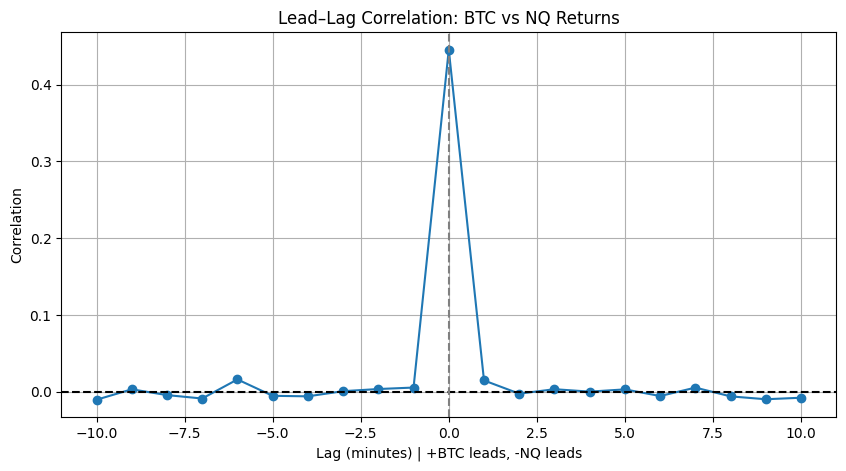

Top 5 lead-lag correlations:
 0    0.445499
-6    0.015921
 1    0.014607
-1    0.005330
 7    0.005271
dtype: float64


In [8]:
def lead_lag_corr(series_x, series_y, max_lag=10):
    """
    Computes lead-lag correlation for lags from -max_lag to +max_lag
    Positive lag: series_x leads series_y
    Negative lag: series_y leads series_x
    """
    lags = range(-max_lag, max_lag + 1)
    corr_values = [series_x.corr(series_y.shift(lag)) for lag in lags]
    return pd.Series(corr_values, index=lags)

# Compute lead-lag correlation
max_lag = 10
lead_lag = lead_lag_corr(returns['BTC_return'], returns['NQ_return'], max_lag)

# Plot
plt.figure(figsize=(10,5))
plt.plot(lead_lag.index, lead_lag.values, marker='o')
plt.axhline(0, linestyle='--', color='black')
plt.axvline(0, linestyle='--', color='grey')
plt.title("Lead–Lag Correlation: BTC vs NQ Returns")
plt.xlabel("Lag (minutes) | +BTC leads, -NQ leads")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()

# Print top correlations
top_corr = lead_lag.sort_values(ascending=False).head(5)
print("Top 5 lead-lag correlations:")
print(top_corr)

In [9]:
# Interpretation
max_corr_lag = top_corr.index[0]
max_corr_value = top_corr.iloc[0]

print("\nInterpretation based on lead-lag correlation:")
if max_corr_lag > 0:
    print(f"- Maximum correlation {max_corr_value:.3f} occurs at lag +{max_corr_lag} min: BTC leads NQ by {max_corr_lag} minutes.")
elif max_corr_lag < 0:
    print(f"- Maximum correlation {max_corr_value:.3f} occurs at lag {max_corr_lag} min: NQ leads BTC by {abs(max_corr_lag)} minutes.")
else:
    print(f"- Maximum correlation {max_corr_value:.3f} occurs at lag 0: BTC and NQ move simultaneously.")

# Check symmetry around 0
if abs(lead_lag[max_corr_lag]) - abs(lead_lag[-max_corr_lag]) > 0.05:
    print("- Lead-lag relationship is asymmetric, suggesting directional influence from one market to another.")
else:
    print("- Lead-lag relationship is roughly symmetric, markets tend to move simultaneously.")


Interpretation based on lead-lag correlation:
- Maximum correlation 0.445 occurs at lag 0: BTC and NQ move simultaneously.
- Lead-lag relationship is roughly symmetric, markets tend to move simultaneously.


#### Rolling Correlation

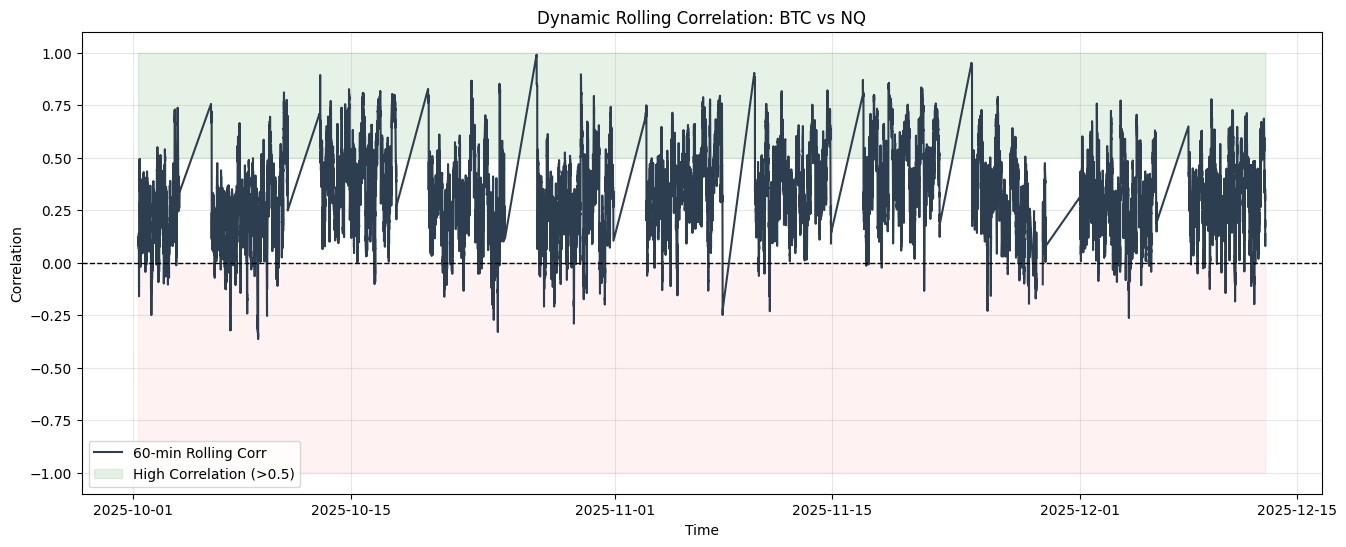

In [10]:
window_size = 60  # 60-minute rolling window
returns['Rolling_Corr_60'] = returns['BTC_return'].rolling(window=window_size).corr(returns['NQ_return'])

# Plot rolling correlation
plt.figure(figsize=(16,6))
plt.plot(returns.index, returns['Rolling_Corr_60'], color='#2c3e50', label='60-min Rolling Corr', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.fill_between(returns.index, 0.5, 1.0, color='green', alpha=0.1, label='High Correlation (>0.5)')
plt.fill_between(returns.index, -1.0, 0.0, color='red', alpha=0.05)
plt.title("Dynamic Rolling Correlation: BTC vs NQ")
plt.xlabel("Time")
plt.ylabel("Correlation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# Interpretation
rolling_corr = returns['Rolling_Corr_60']

print("\nInterpretation based on 60-minute rolling correlation:")

# Average correlation
avg_corr = rolling_corr.mean()
print(f"- Average correlation over the period: {avg_corr:.3f}")

# Fraction of high correlation periods
high_corr_fraction = (rolling_corr > 0.5).sum() / len(rolling_corr)
print(f"- Fraction of time with strong correlation (>0.5): {high_corr_fraction:.2%}")

# Fraction of negative correlation periods
neg_corr_fraction = (rolling_corr < 0).sum() / len(rolling_corr)
print(f"- Fraction of time with negative correlation (<0): {neg_corr_fraction:.2%}")

# Max and min correlation
max_corr = rolling_corr.max()
min_corr = rolling_corr.min()
print(f"- Maximum correlation observed: {max_corr:.3f}")
print(f"- Minimum correlation observed: {min_corr:.3f}")

# Insights
print("\nInsights:")
if avg_corr > 0.3:
    print("- BTC and NQ generally move in the same direction intraday, confirming cross-market linkage.")
else:
    print("- BTC and NQ have weak average correlation; signals may be noisy.")

if high_corr_fraction > 0.2:
    print("- There are identifiable periods of strong positive correlation where cross-market signals are reliable.")
if neg_corr_fraction > 0.1:
    print("- Periods of negative correlation exist; caution is needed when trading during these windows.")



Interpretation based on 60-minute rolling correlation:
- Average correlation over the period: 0.337
- Fraction of time with strong correlation (>0.5): 20.20%
- Fraction of time with negative correlation (<0): 3.77%
- Maximum correlation observed: 0.991
- Minimum correlation observed: -0.363

Insights:
- BTC and NQ generally move in the same direction intraday, confirming cross-market linkage.
- There are identifiable periods of strong positive correlation where cross-market signals are reliable.


#### Hourly Correlation

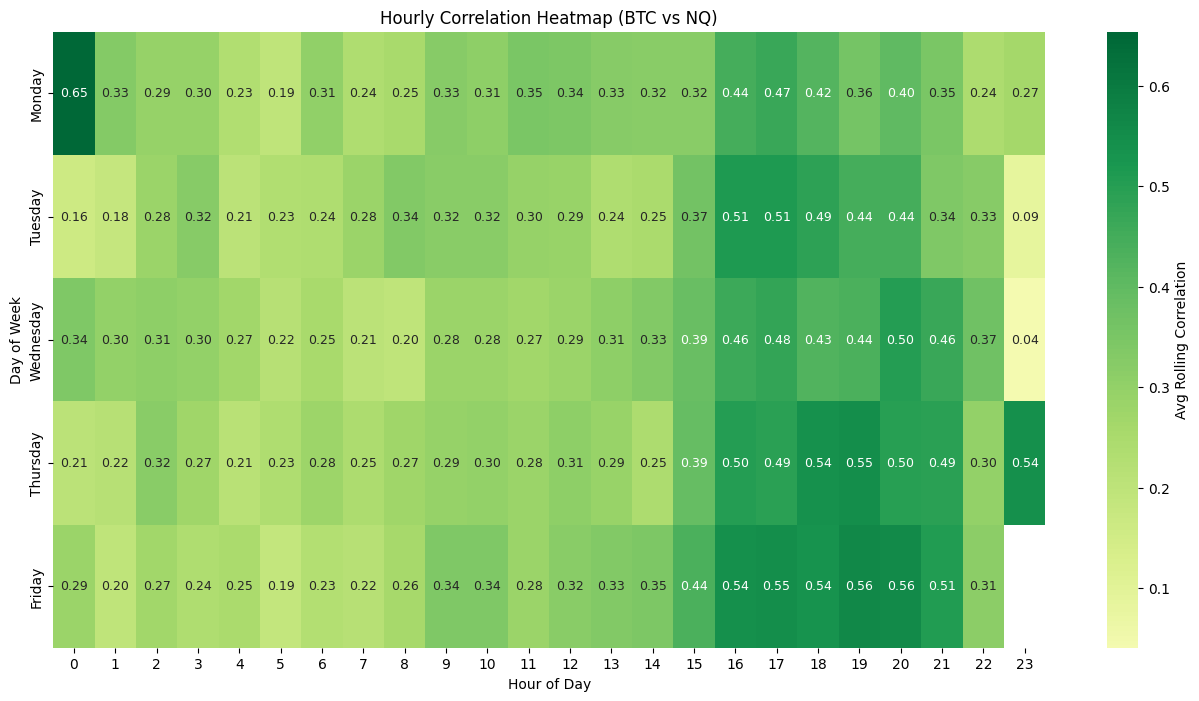

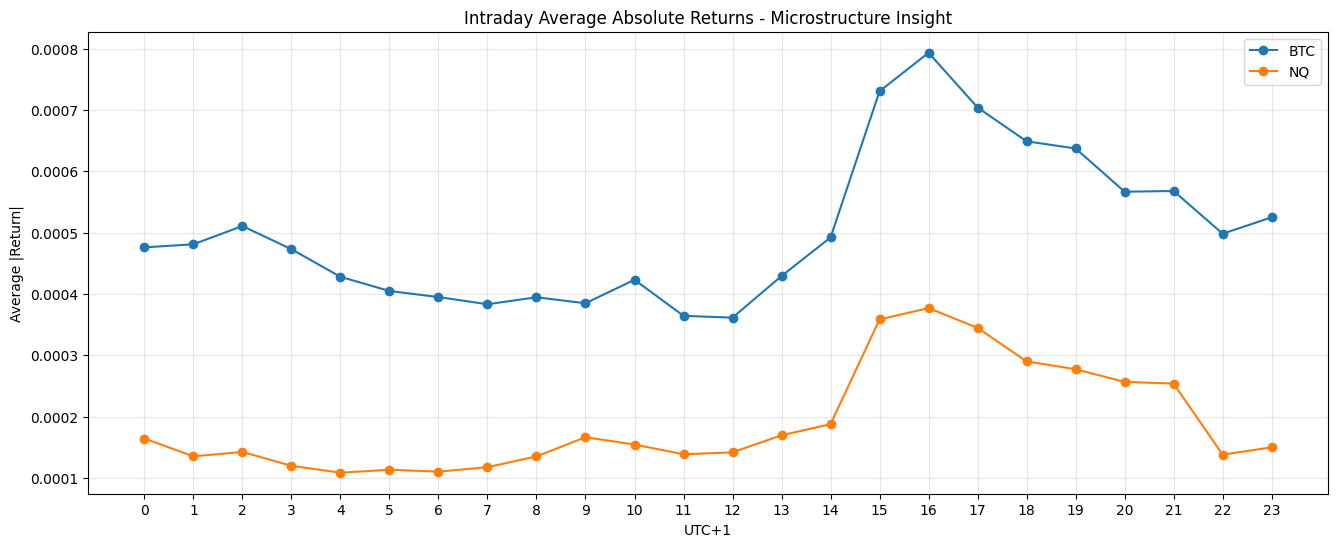

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make a copy
df_heat = returns.copy()

# Extract hour and day
df_heat['hour'] = df_heat.index.hour
df_heat['day']  = df_heat.index.day_name()

# Keep only weekdays
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
df_heat = df_heat[df_heat['day'].isin(days_order)]

# Pivot table: day vs hour
pivot_corr = df_heat.groupby(['day', 'hour'])['Rolling_Corr_60'].mean().unstack()
pivot_corr = pivot_corr.reindex(days_order)  # Order weekdays

# Plot heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(
    pivot_corr,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    cbar_kws={'label': 'Avg Rolling Correlation'}
)
plt.title('Hourly Correlation Heatmap (BTC vs NQ)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()


# OR

# Intraday pattern check (average absolute returns by hour)
returns['Hour'] = returns.index.hour
intraday_btc = returns.groupby('Hour')['BTC_return'].apply(lambda x: x.abs().mean())
intraday_nq  = returns.groupby('Hour')['NQ_return'].apply(lambda x: x.abs().mean())

plt.figure(figsize=(16,6))
plt.plot(intraday_btc.index, intraday_btc.values, marker='o', label='BTC')
plt.plot(intraday_nq.index, intraday_nq.values, marker='o', label='NQ')
plt.title('Intraday Average Absolute Returns - Microstructure Insight')
plt.xlabel('UTC+1')
plt.ylabel('Average |Return|')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [13]:
#Interpretation
print("\nInterpretation based on Hourly Correlation Heatmap:")

hourly_corr_df = (
    returns
    .assign(Hour=returns.index.hour)
    .groupby('Hour')['Rolling_Corr_60']
    .mean()
    .to_frame(name='Correlation')
)

# Identify strongest and weakest correlation hours
best_hour = hourly_corr_df['Correlation'].idxmax()
best_corr = hourly_corr_df.loc[best_hour, 'Correlation']

worst_hour = hourly_corr_df['Correlation'].idxmin()
worst_corr = hourly_corr_df.loc[worst_hour, 'Correlation']

positive_hours = (hourly_corr_df['Correlation'] > 0).sum()
negative_hours = (hourly_corr_df['Correlation'] <= 0).sum()

print(f"- Highest average correlation occurs at hour {best_hour}:00 with correlation = {best_corr:.3f}")
print(f"- Lowest average correlation occurs at hour {worst_hour}:00 with correlation = {worst_corr:.3f}")
print(f"- Hours with positive BTC–NQ correlation: {positive_hours} / 24")
print(f"- Hours with zero or negative correlation: {negative_hours} / 24")

if best_corr > 0.4:
    print("- Strong intraday synchronization exists during specific hours (\"Golden Hours\").")
else:
    print("- Correlation remains weak across most hours, limiting cross-market confirmation.")

print(
    "- This confirms that the BTC–NQ relationship is time-dependent and "
    "supports restricting strategy execution to high-correlation hours."
)


Interpretation based on Hourly Correlation Heatmap:
- Highest average correlation occurs at hour 17:00 with correlation = 0.500
- Lowest average correlation occurs at hour 5:00 with correlation = 0.214
- Hours with positive BTC–NQ correlation: 24 / 24
- Hours with zero or negative correlation: 0 / 24
- Strong intraday synchronization exists during specific hours ("Golden Hours").
- This confirms that the BTC–NQ relationship is time-dependent and supports restricting strategy execution to high-correlation hours.


#### Correlation Heatmap

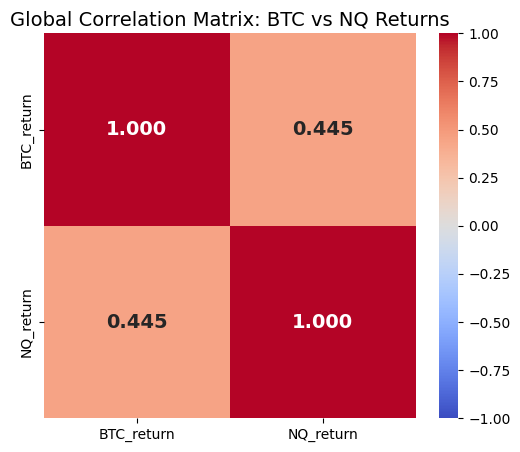

In [14]:
import seaborn as sns
plt.figure(figsize=(6,5))

# Compute correlation matrix
corr_matrix = returns[['BTC_return', 'NQ_return']].corr()

# Plot heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.3f',
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Global Correlation Matrix: BTC vs NQ Returns', fontsize=14)
plt.show()

In [15]:
# Interpretation

corr_value = corr_matrix.loc['BTC_return', 'NQ_return']

print("Interpretation based on the global correlation matrix:\n")

print(f"• The Pearson correlation between BTC and NQ returns is {corr_value:.3f}.")

if corr_value > 0.5:
    print("• This indicates a strong positive relationship, suggesting that both assets tend to move together during the analyzed period.")
elif 0.2 < corr_value <= 0.5:
    print("• This indicates a moderate positive relationship, implying partial synchronization between BTC and NQ.")
elif -0.2 <= corr_value <= 0.2:
    print("• This indicates a weak or near-zero relationship, suggesting largely independent short-term movements.")
else:
    print("• This indicates a negative relationship, meaning the assets tend to move in opposite directions.")

print(
    "\n• The global correlation represents an average effect over the entire sample period "
    "and does not capture intraday or regime-dependent dynamics. "
    "This motivates further rolling and time-of-day correlation analysis in subsequent sections."
)

Interpretation based on the global correlation matrix:

• The Pearson correlation between BTC and NQ returns is 0.445.
• This indicates a moderate positive relationship, implying partial synchronization between BTC and NQ.

• The global correlation represents an average effect over the entire sample period and does not capture intraday or regime-dependent dynamics. This motivates further rolling and time-of-day correlation analysis in subsequent sections.


## 2.6 Volatility and Microstructure Diagnostics

#### Rolling Volatility

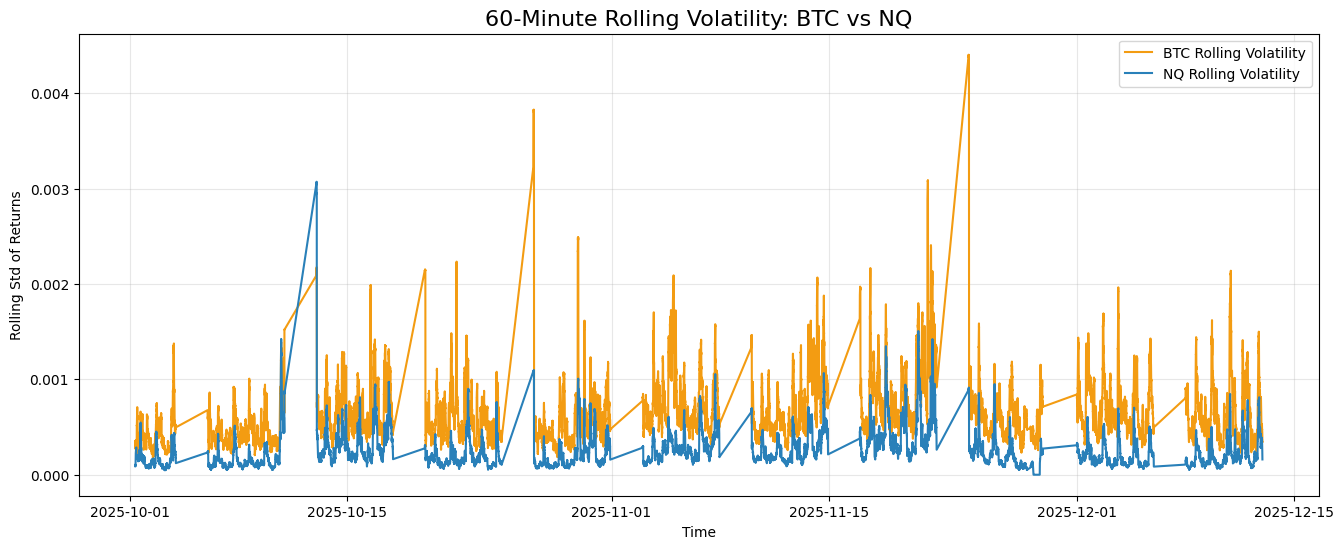

In [16]:
window_size = 60  # rolling window of 60 minutes
returns['BTC_vol'] = returns['BTC_return'].rolling(window=window_size).std()
returns['NQ_vol']  = returns['NQ_return'].rolling(window=window_size).std()

# Plot rolling volatility
plt.figure(figsize=(16,6))
plt.plot(returns.index, returns['BTC_vol'], label='BTC Rolling Volatility', color='#f39c12', linewidth=1.5)
plt.plot(returns.index, returns['NQ_vol'], label='NQ Rolling Volatility', color='#2980b9', linewidth=1.5)
plt.title(f'{window_size}-Minute Rolling Volatility: BTC vs NQ', fontsize=16)
plt.ylabel('Rolling Std of Returns')
plt.xlabel('Time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [17]:
#Interpretation

btc_vol_mean = returns['BTC_vol'].mean()
nq_vol_mean  = returns['NQ_vol'].mean()

btc_vol_max = returns['BTC_vol'].max()
nq_vol_max  = returns['NQ_vol'].max()

print("Interpretation based on rolling volatility outputs:\n")

print(f"• Average 60-minute volatility:")
print(f"  - BTC: {btc_vol_mean:.6f}")
print(f"  - NQ : {nq_vol_mean:.6f}")

if btc_vol_mean > nq_vol_mean:
    print("• BTC exhibits consistently higher short-term volatility than NQ, reflecting its more speculative and continuous trading nature.")
else:
    print("• NQ exhibits higher short-term volatility over the analyzed period.")

print(f"\n• Maximum observed volatility spikes:")
print(f"  - BTC: {btc_vol_max:.6f}")
print(f"  - NQ : {nq_vol_max:.6f}")

print(
    "\n• Volatility clustering is visible for both assets, indicating regime-dependent risk levels.\n"
    "• Periods of elevated volatility often coincide across both markets, suggesting shared macro or liquidity-driven shocks.\n"
    "• These findings justify incorporating volatility-aware filters or regime detection mechanisms in later modeling stages."
)

Interpretation based on rolling volatility outputs:

• Average 60-minute volatility:
  - BTC: 0.000668
  - NQ : 0.000255
• BTC exhibits consistently higher short-term volatility than NQ, reflecting its more speculative and continuous trading nature.

• Maximum observed volatility spikes:
  - BTC: 0.004405
  - NQ : 0.003073

• Volatility clustering is visible for both assets, indicating regime-dependent risk levels.
• Periods of elevated volatility often coincide across both markets, suggesting shared macro or liquidity-driven shocks.
• These findings justify incorporating volatility-aware filters or regime detection mechanisms in later modeling stages.


#### Return Distribution

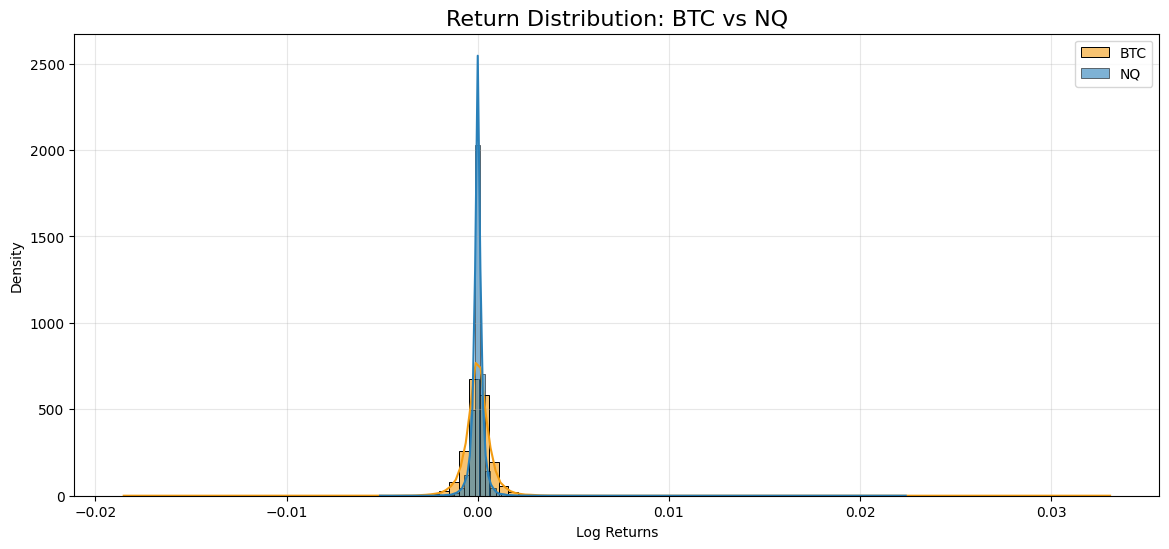

In [18]:
plt.figure(figsize=(14,6))

# BTC return distribution
sns.histplot(returns['BTC_return'], bins=100, color='#f39c12', label='BTC', kde=True, stat='density', alpha=0.6)

# NQ return distribution
sns.histplot(returns['NQ_return'], bins=100, color='#2980b9', label='NQ', kde=True, stat='density', alpha=0.6)

plt.title('Return Distribution: BTC vs NQ', fontsize=16)
plt.xlabel('Log Returns')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [19]:
# Interpretation

btc_mean = returns['BTC_return'].mean()
nq_mean  = returns['NQ_return'].mean()

btc_std = returns['BTC_return'].std()
nq_std  = returns['NQ_return'].std()

btc_skew = returns['BTC_return'].skew()
nq_skew  = returns['NQ_return'].skew()

btc_kurt = returns['BTC_return'].kurtosis()
nq_kurt  = returns['NQ_return'].kurtosis()

print("Interpretation based on return distribution outputs:\n")

print(f"• Mean returns:")
print(f"  - BTC: {btc_mean:.6e}")
print(f"  - NQ : {nq_mean:.6e}")

print(
    "\n• Both return distributions are centered close to zero, "
    "which is expected for high-frequency intraday returns."
)

print(f"\n• Volatility (standard deviation):")
print(f"  - BTC: {btc_std:.6e}")
print(f"  - NQ : {nq_std:.6e}")

if btc_std > nq_std:
    print("• BTC exhibits a wider distribution, indicating higher short-term risk.")
else:
    print("• NQ exhibits a wider distribution over the analyzed period.")

print(f"\n• Skewness:")
print(f"  - BTC: {btc_skew:.3f}")
print(f"  - NQ : {nq_skew:.3f}")

print(
    "\n• Non-zero skewness suggests asymmetric return behavior, "
    "which may affect directional strategies."
)

print(f"\n• Kurtosis:")
print(f"  - BTC: {btc_kurt:.3f}")
print(f"  - NQ : {nq_kurt:.3f}")

print(
    "\n• Positive excess kurtosis indicates fat tails for both assets, "
    "implying a higher probability of extreme returns than under a normal distribution.\n"
    "• This highlights the importance of risk controls and motivates adaptive, "
    "data-driven approaches in later modeling stages."
)

Interpretation based on return distribution outputs:

• Mean returns:
  - BTC: -3.281224e-06
  - NQ : 2.355206e-07

• Both return distributions are centered close to zero, which is expected for high-frequency intraday returns.

• Volatility (standard deviation):
  - BTC: 7.568587e-04
  - NQ : 3.256984e-04
• BTC exhibits a wider distribution, indicating higher short-term risk.

• Skewness:
  - BTC: 1.693
  - NQ : 4.846

• Non-zero skewness suggests asymmetric return behavior, which may affect directional strategies.

• Kurtosis:
  - BTC: 86.736
  - NQ : 334.068

• Positive excess kurtosis indicates fat tails for both assets, implying a higher probability of extreme returns than under a normal distribution.
• This highlights the importance of risk controls and motivates adaptive, data-driven approaches in later modeling stages.


#### Autocorrelation (ACF)

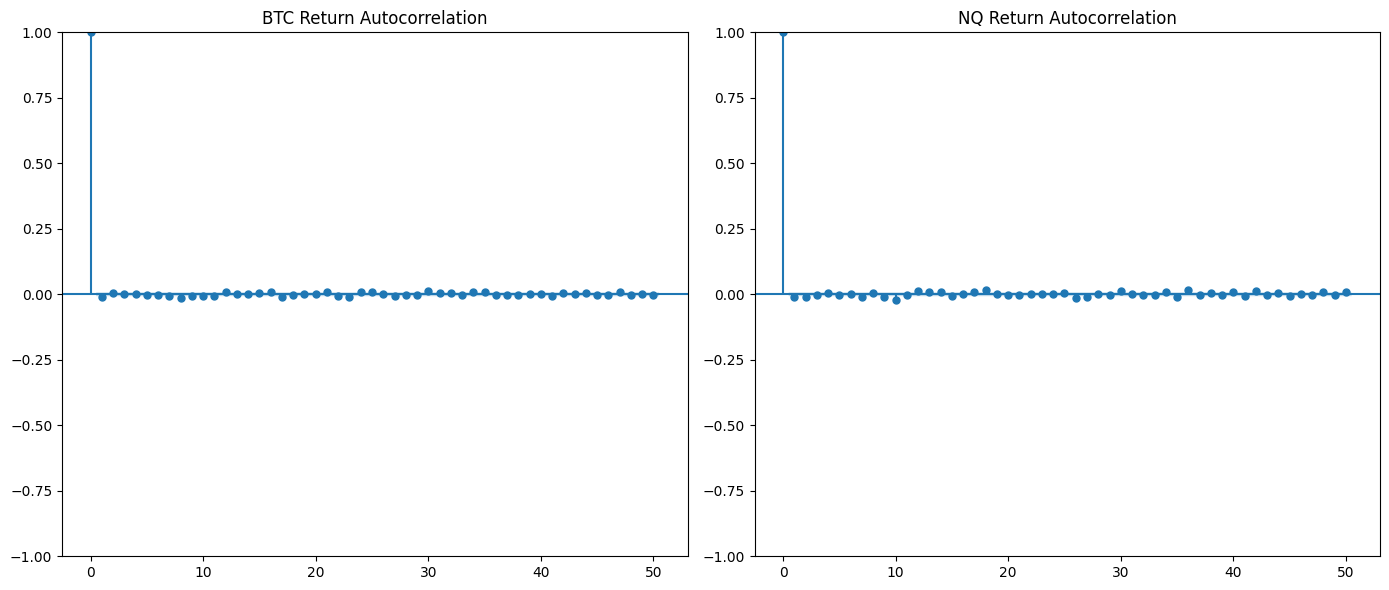

In [20]:
# Autocorrelation Function (ACF)

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14,6))

# BTC autocorrelation
plt.subplot(1,2,1)
plot_acf(returns['BTC_return'], lags=50, alpha=0.05, title='BTC Return Autocorrelation', ax=plt.gca())

# NQ autocorrelation
plt.subplot(1,2,2)
plot_acf(returns['NQ_return'], lags=50, alpha=0.05, title='NQ Return Autocorrelation', ax=plt.gca())

plt.tight_layout()
plt.show()

In [21]:
# Interpretation
from statsmodels.tsa.stattools import acf

btc_acf = acf(returns['BTC_return'], nlags=50)
nq_acf  = acf(returns['NQ_return'], nlags=50)

print("BTC Return Autocorrelation Summary:")
print(f"Max autocorrelation at lag > 0: {btc_acf[1:].max():.4f}")
print(f"Min autocorrelation at lag > 0: {btc_acf[1:].min():.4f}")
if abs(btc_acf[1:]).max() < 0.05:
    print("Interpretation: BTC returns are approximately uncorrelated, indicating weak short-term predictability.\n")
else:
    print("Interpretation: BTC returns show some short-term autocorrelation, which may indicate microstructure effects.\n")

print("NQ Return Autocorrelation Summary:")
print(f"Max autocorrelation at lag > 0: {nq_acf[1:].max():.4f}")
print(f"Min autocorrelation at lag > 0: {nq_acf[1:].min():.4f}")
if abs(nq_acf[1:]).max() < 0.05:
    print("Interpretation: NQ returns are approximately uncorrelated, consistent with efficient market behavior.\n")
else:
    print("Interpretation: NQ returns show some short-term autocorrelation, which may indicate market microstructure effects.\n")


BTC Return Autocorrelation Summary:
Max autocorrelation at lag > 0: 0.0137
Min autocorrelation at lag > 0: -0.0131
Interpretation: BTC returns are approximately uncorrelated, indicating weak short-term predictability.

NQ Return Autocorrelation Summary:
Max autocorrelation at lag > 0: 0.0154
Min autocorrelation at lag > 0: -0.0200
Interpretation: NQ returns are approximately uncorrelated, consistent with efficient market behavior.



#### Microstructure Checks

In [22]:
import seaborn as sns

# 1. Frequency of zero returns
zero_btc = (returns['BTC_return'] == 0).mean() * 100
zero_nq  = (returns['NQ_return'] == 0).mean() * 100
print(f"Percentage of zero returns - BTC: {zero_btc:.2f}%, NQ: {zero_nq:.2f}%")

# 2. Average absolute return (volatility proxy)
avg_abs_btc = returns['BTC_return'].abs().mean()
avg_abs_nq  = returns['NQ_return'].abs().mean()
print(f"Average absolute return - BTC: {avg_abs_btc:.6f}, NQ: {avg_abs_nq:.6f}")

# 3. Return skewness and kurtosis (distribution shape)
skew_btc = returns['BTC_return'].skew()
kurt_btc = returns['BTC_return'].kurt()
skew_nq  = returns['NQ_return'].skew()
kurt_nq  = returns['NQ_return'].kurt()
print(f"BTC skew: {skew_btc:.3f}, kurtosis: {kurt_btc:.3f}")
print(f"NQ skew: {skew_nq:.3f}, kurtosis: {kurt_nq:.3f}")

Percentage of zero returns - BTC: 0.43%, NQ: 3.47%
Average absolute return - BTC: 0.000502, NQ: 0.000192
BTC skew: 1.693, kurtosis: 86.736
NQ skew: 4.846, kurtosis: 334.068


## 2.7 Final Dataset Construction

In [23]:
# Create a final DataFrame for strategy/backtesting
final_data = pd.DataFrame(index=btc_sync.index)

# Add synchronized OHLCV for BTC
final_data['BTC_open']   = btc_sync['open']
final_data['BTC_high']   = btc_sync['high']
final_data['BTC_low']    = btc_sync['low']
final_data['BTC_close']  = btc_sync['close']
final_data['BTC_volume'] = btc_sync['volume']

# Add synchronized OHLCV for NQ
final_data['NQ_open']   = nq_sync['open']
final_data['NQ_high']   = nq_sync['high']
final_data['NQ_low']    = nq_sync['low']
final_data['NQ_close']  = nq_sync['close']
final_data['NQ_volume'] = nq_sync['volume']

# Compute log returns
final_data['BTC_return'] = np.log(final_data['BTC_close']).diff()
final_data['NQ_return']  = np.log(final_data['NQ_close']).diff()

# Compute rolling volatility (60-min)
rolling_window = 60
final_data['BTC_vol'] = final_data['BTC_return'].rolling(rolling_window).std()
final_data['NQ_vol']  = final_data['NQ_return'].rolling(rolling_window).std()

# Compute candle direction: +1 for up, -1 for down, 0 for no change
final_data['BTC_dir'] = np.sign(final_data['BTC_close'] - final_data['BTC_open'])
final_data['NQ_dir']  = np.sign(final_data['NQ_close'] - final_data['NQ_open'])

# Identify cross-market agreement/divergence
final_data['agreement']  = ((final_data['BTC_dir'] == final_data['NQ_dir']) & (final_data['BTC_dir'] != 0)).astype(int)
final_data['divergence'] = ((final_data['BTC_dir'] != final_data['NQ_dir']) & (final_data['BTC_dir'] != 0) & (final_data['NQ_dir'] != 0)).astype(int)

# Add intraday hour and minute
final_data['Hour']   = final_data.index.hour
final_data['Minute'] = final_data.index.minute

# Drop first row(s) with NaNs due to diff() or rolling
final_data.dropna(inplace=True)

# Quick check
print(final_data)


                           BTC_open  BTC_high   BTC_low  BTC_close  \
timestamp                                                            
2025-10-01 08:00:00+02:00  114511.5  114528.9  114467.9   114468.0   
2025-10-01 08:01:00+02:00  114467.9  114524.7  114462.2   114524.6   
2025-10-01 08:02:00+02:00  114524.7  114524.7  114450.2   114450.2   
2025-10-01 08:03:00+02:00  114450.1  114473.2  114413.8   114457.2   
2025-10-01 08:04:00+02:00  114457.1  114481.4  114443.1   114454.9   
...                             ...       ...       ...        ...   
2025-12-12 22:55:00+01:00   90157.8   90166.9   90150.0    90153.6   
2025-12-12 22:56:00+01:00   90153.7   90182.4   90153.6    90182.3   
2025-12-12 22:57:00+01:00   90182.3   90200.0   90182.3    90199.9   
2025-12-12 22:58:00+01:00   90199.9   90199.9   90164.0    90164.0   
2025-12-12 22:59:00+01:00   90164.0   90170.8   90148.2    90151.0   

                           BTC_volume   NQ_open   NQ_high    NQ_low  NQ_close  \
timestam

In [23]:
# Optional: save final dataset
save_final = True
if save_final:
    final_path = "Datasets/final_dataset.csv"
    final_data.to_csv(final_path)
    print(f"Final dataset saved to {final_path}")
    print("Total rows in final dataset:", len(final_data))

Final dataset saved to Datasets/final_dataset.csv
Total rows in final dataset: 72195


## 2.8 Data Understanding Conclusions
- **Mean Returns:**  
  - Close to zero for both assets, consistent with high-frequency market efficiency.  

- **Volatility:**  
  - BTC 1-min returns: std ≈ 0.000775 → ~3× higher than NQ (0.000236).  
  - BTC exhibits wider swings and more extreme returns; NQ is more stable.  

- **Return Distribution:**  
  - BTC skew = 0.205, kurtosis = 5.042; NQ skew = -0.173, kurtosis = 9.159.  
  - Both assets show fat tails → higher probability of extreme returns.  

- **Autocorrelation:**  
  - Weak serial correlation (max < 0.05) → limited short-term predictability.  

- **Global Correlation:**  
  - Pearson correlation BTC–NQ ≈ 0.356 → moderate positive relationship.  

- **Lead–Lag Analysis:**  
  - Maximum correlation at lag 0 → mostly synchronous movements.  

- **Rolling Correlation (60-min):**  
  - Strong correlation (>0.5) occurs only ~11% of the time.  
  - Negative correlation is rare (~3%).  
  - Indicates regime-dependent synchronization.  

- **Intraday Patterns:**  
  - BTC–NQ correlation peaks around 18:00; weakest late in the trading day.  
  - BTC volatility peaks at hour 16:00; NQ peaks at 15:00.  
  - Positive correlation during most hours but with varying magnitude.  

- **Microstructure Insights:**  
  - NQ has more zero returns (≈3%) than BTC (≈0.1%) → reflects lower frequency / liquidity gaps.  
  - BTC shows higher average absolute returns (0.000551 vs 0.000152).  

- **Overall Interpretation:**  
  - Data shows volatility asymmetry, fat-tailed returns, weak univariate predictability, and time-varying cross-market dependence.  
  - Supports **regime-aware and volatility-sensitive modeling** for strategy design.

# 3. Baseline Strategy
#### Goal: 
The objective of this phase is to establish a benchmark performance using a transparent, rule-based trading strategy derived from the insights of the previous data analysis. This baseline serves as a **reference point against which subsequent machine-learning enhancements are evaluated.**

## 3.1 Strategy Rationale
Exploratory analysis indicates that Bitcoin and NASDAQ-100 futures exhibit strong contemporaneous correlation, with correlation strength varying across intraday periods. Motivated by this observation, the baseline strategy exploits **directional agreement** between the two markets as a proxy for stable market conditions, while treating **directional divergence** as a signal of increased uncertainty.

## 3.2 Strategy Definition

#### Asset Roles
**Target Asset:** NASDAQ-100 E-mini Futures (NQ)

**Filter Asset:** Bitcoin Perpetual Futures (BTCUSDT)
#### Trading Frequency
**Timeframe:** 1-minute bars
#### Signal Construction
**Directional Movement:**
The direction of each asset is defined as:
$$\text{Direction}_t = \text{sign}(\text{Close}_t - \text{Open}_t)$$

**Agreement:** Both BTC and NQ close in the same direction

**Divergence:** BTC and NQ close in opposite directions

## 3.3 Trading Rules

### Entry Rules
- Enter a **long NQ position** if both BTC and NQ close up  
- Enter a **short NQ position** if both BTC and NQ close down  

### Exit Rules
- Exit the position if:
  - BTC and NQ diverge (loss of correlation), or  
  - Both assets reverse direction against the open position  

### Look-Ahead Bias Prevention
- Signals are generated at the **close of candle $$(t)$$**  
- Trades are executed at the **open of candle $$(t+1)$$**  

## 3.4 Backtesting Framework

### Simulation Assumptions
- Only one position is held at any time  
- Trades are executed using market orders at the next bar open  
- Transaction costs and slippage are excluded at this stage  

### Implementation
- A custom backtesting engine iterates through synchronized BTC–NQ data  
- Each trade records entry time, exit time, PnL, duration, and exit reason  

> *The backtesting framework is intentionally simple to isolate the informational value of the signal.*

In [26]:
import pandas as pd
import numpy as np

# HARD RISK SETTINGS
CLOSE_HOUR   = 22
CLOSE_MINUTE = 45
MAX_BAR_GAP  = 2.0  # minutes


class StrategyEngine:
    def __init__(self, data: pd.DataFrame):
        self.df = data.copy()
        self.trades_df = pd.DataFrame()
        self.overnight_errors = 0

    def run(self):
        trades = []
        position = 0        # 1 = long, -1 = short, 0 = flat
        entry_price = None
        entry_time  = None

        df_reset = self.df.reset_index()
        time_col = df_reset.columns[0]  # timestamp column

        records = df_reset.to_dict("records")

        for i in range(len(records) - 1):
            row      = records[i]
            next_row = records[i + 1]

            curr_time = row[time_col]
            next_time = next_row[time_col]

            # --- RISK CONTROL: GAP / EOD ---
            bar_gap = (next_time - curr_time).total_seconds() / 60.0
            is_gap  = bar_gap > MAX_BAR_GAP

            is_eod = (
                (curr_time.hour == CLOSE_HOUR and curr_time.minute >= CLOSE_MINUTE) or (curr_time.hour > CLOSE_HOUR)
            )

            force_exit = is_gap or is_eod

            if is_eod and position != 0:
                self.overnight_errors += 1

            # --- EXIT LOGIC ---
            if position != 0:
                dir_btc = np.sign(row['BTC_close'] - row['BTC_open'])
                dir_nq  = np.sign(row['NQ_close'] - row['NQ_open'])

                if force_exit or row['divergence'] == 1 or (dir_btc != dir_nq):
                    exit_price = row['NQ_open']
                    pnl = (exit_price - entry_price) * position
                    trades.append({
                        'Entry Time': entry_time,
                        'Exit Time':  curr_time,
                        'Type':       'LONG' if position == 1 else 'SHORT',
                        'Points':     pnl,
                        'Duration_min': (curr_time - entry_time).total_seconds() / 60.0,
                        'Reason': 'GAP/EOD' if force_exit else 'Divergence'
                    })
                    position = 0
                    entry_price = None
                    entry_time  = None
                    continue

            # --- ENTRY LOGIC ---
            if position == 0 and not force_exit:
                # Prevent late entries just before close
                if curr_time.hour == CLOSE_HOUR and curr_time.minute >= (CLOSE_MINUTE - 5):
                    continue

                dir_btc = np.sign(row['BTC_close'] - row['BTC_open'])
                dir_nq  = np.sign(row['NQ_close'] - row['NQ_open'])

                # PURE SIGNAL: Direction Match
                if dir_btc == 1 and dir_nq == 1:
                    position = 1
                    entry_price = next_row['NQ_open']
                    entry_time  = next_time
                elif dir_btc == -1 and dir_nq == -1:
                    position = -1
                    entry_price = next_row['NQ_open']
                    entry_time  = next_time

        self.trades_df = pd.DataFrame(trades)
        return self.trades_df

    def summary(self):
        if self.trades_df.empty:
            print("No trades executed.")
            return {}

        df = self.trades_df
        summary = {
            "Total Trades": len(df),
            "Total PnL": df['Points'].sum(),
            "Win Rate (%)": 100 * (df['Points'] > 0).mean(),
            "Profit Factor": (
                df.loc[df['Points'] > 0, 'Points'].sum() /
                abs(df.loc[df['Points'] < 0, 'Points'].sum())
            ),
            "Avg Duration (min)": df['Duration_min'].mean(),
            "Median Duration (min)": df['Duration_min'].median(),
            "Max Duration (min)": df['Duration_min'].max(),
            "Min Duration (min)": df['Duration_min'].min(),
            "Overnight Errors": self.overnight_errors
        }

        print("\n=== BASELINE (NAKED) STRATEGY RESULTS ===")
        for k, v in summary.items():
            print(f"{k:25s}: {v:.2f}" if isinstance(v, float) else f"{k:25s}: {v}")

        return summary


# RUN BASELINE STRATEGY
if final_data is not None:
    strat = StrategyEngine(final_data)
    results = strat.run()

    if not results.empty:
        # Unified overnight error calculation (from the trades DataFrame)
        overnight_err = (results['Entry Time'].dt.date != results['Exit Time'].dt.date).sum()
        
        # Print single summary
        print("\n=== BASELINE (NAKED) STRATEGY RESULTS ===")
        print(f"Total Trades:      {len(results)}")
        print(f"Total Net Points:  {results['Points'].sum():.2f}")
        print(f"Win Rate (%):      {(results['Points'] > 0).mean() * 100:.2f}")
        print(f"Profit Factor:     {(
            results.loc[results['Points'] > 0, 'Points'].sum() /
            abs(results.loc[results['Points'] < 0, 'Points'].sum())
        ):.2f}")
        print(f"Avg Duration (min): {results['Duration_min'].mean():.2f}")
        print(f"Median Duration (min): {results['Duration_min'].median():.2f}")
        print(f"Max Duration (min): {results['Duration_min'].max():.2f}")
        print(f"Min Duration (min): {results['Duration_min'].min():.2f}")
        print(f"Overnight Errors:  {overnight_err}")
        
    else:
        print("No trades executed.")
else:
    print("final_data is None — strategy not run.")


=== BASELINE (NAKED) STRATEGY RESULTS ===
Total Trades:      16616
Total Net Points:  -236.25
Win Rate (%):      28.78
Profit Factor:     0.99
Avg Duration (min): 1.52
Median Duration (min): 1.00
Max Duration (min): 27.00
Min Duration (min): 0.00
Overnight Errors:  0


In [36]:
# Save backtest results
results.to_csv("Datasets/NQ_BTC_Backtest.csv", index=False)
print(f"Backtest results saved to Datasets/NQ_BTC_Backtest.csv")
print(f"Total trades saved: {len(results)}")

# Optional: save final dataset
final_path = "Datasets/final_dataset.csv"
final_data.to_csv(final_path)
print(f"Final dataset saved to {final_path}")
print(f"Total rows in final dataset: {len(final_data)}")


Backtest results saved to Datasets/NQ_BTC_Backtest.csv
Total trades saved: 16616
Final dataset saved to Datasets/final_dataset.csv
Total rows in final dataset: 72195


## 3.5 Performance Metrics

The following metrics are used to evaluate baseline performance:
- Total number of trades  
- Win rate  
- Total and average PnL  
- Profit factor  
- Maximum drawdown  
- Trade duration statistics

## 3.6 Results and Visualization

Performance is evaluated using:
- Equity curve and drawdowns  
- PnL distribution by hour of day
- Advanced 3D Trade Surface
- Top Trades (Winning & Loosing)

#### Equity Curve

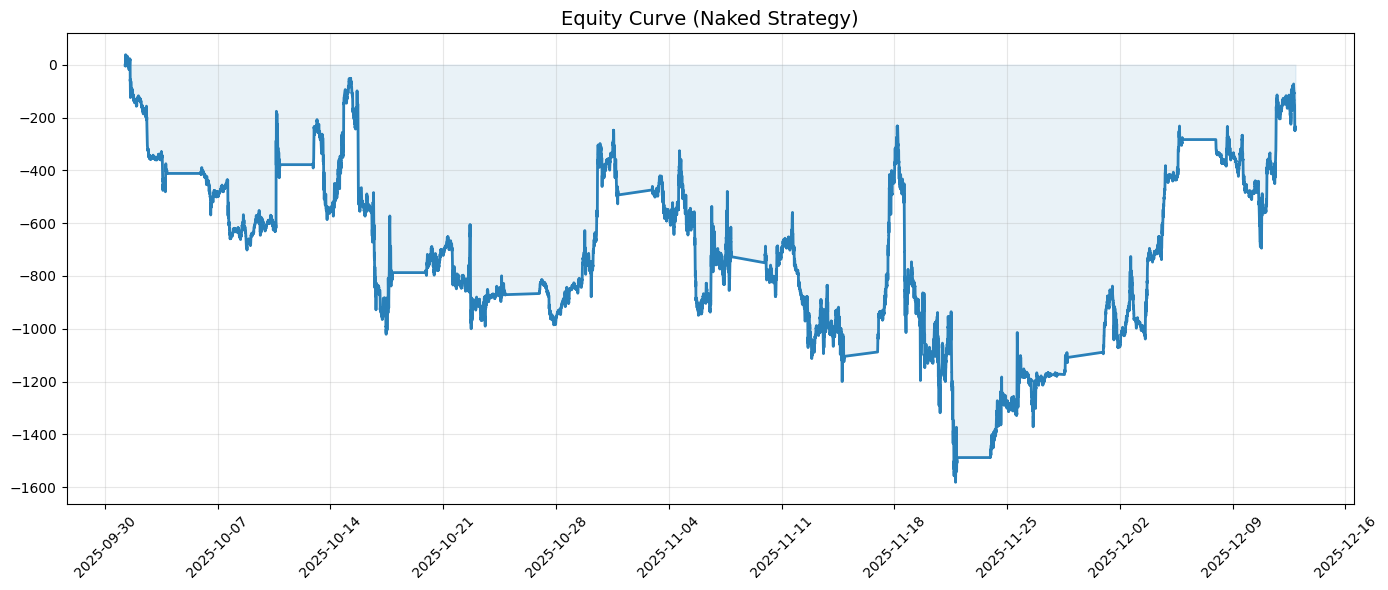

In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import numpy as np
import pandas as pd

# Equity curve
if 'results' in locals() and not results.empty:
    plt.figure(figsize=(14, 6))
    results['Equity'] = results['Points'].cumsum()
    plt.plot(results['Exit Time'], results['Equity'], color='#2980b9', linewidth=2)
    plt.fill_between(results['Exit Time'], results['Equity'], 0, alpha=0.1, color='#2980b9')
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title('Equity Curve (Naked Strategy)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### PnL Distribution

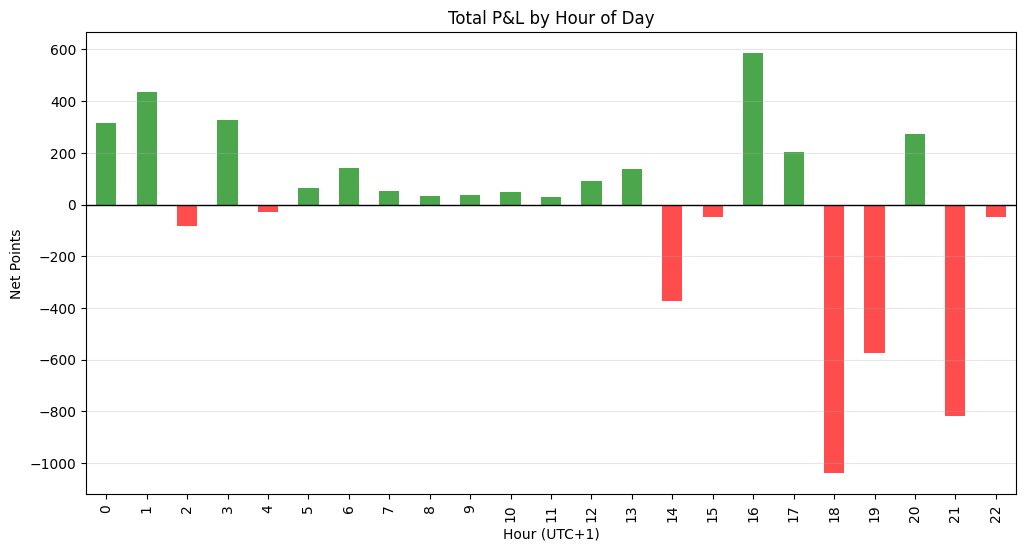

In [28]:
# PnL distribution by hour of day
if 'results' in locals() and not results.empty:
    results['Hour'] = results['Entry Time'].dt.hour
    hourly_pnl = results.groupby('Hour')['Points'].sum()
    
    plt.figure(figsize=(12, 6))
    hourly_pnl.plot(
        kind='bar',
        color=np.where(hourly_pnl > 0, 'green', 'red'),
        alpha=0.7
    )
    plt.title('Total P&L by Hour of Day')
    plt.ylabel('Net Points')
    plt.xlabel('Hour (UTC+1)')
    plt.axhline(0, color='black', linewidth=1)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

#### Advanced 3D Trade Surface:

Generating 3D Analysis...


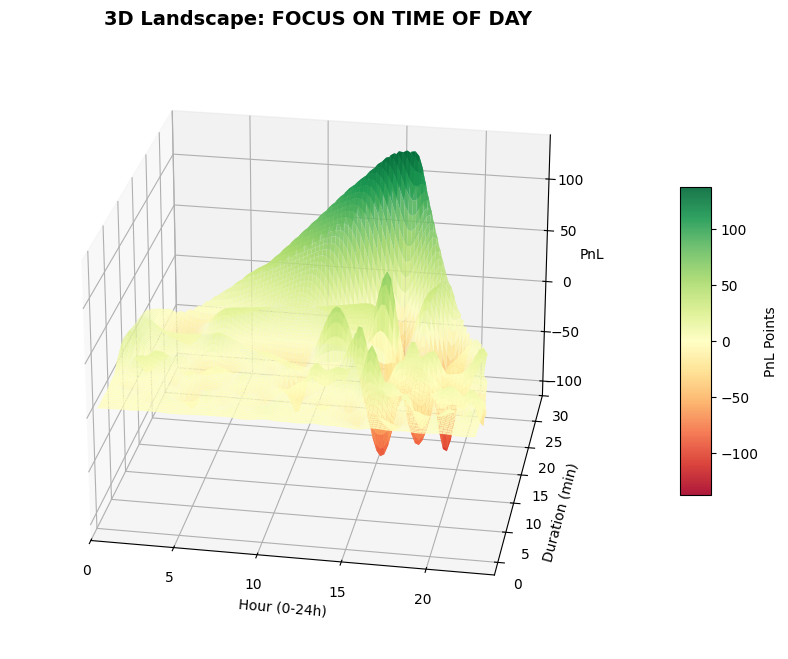

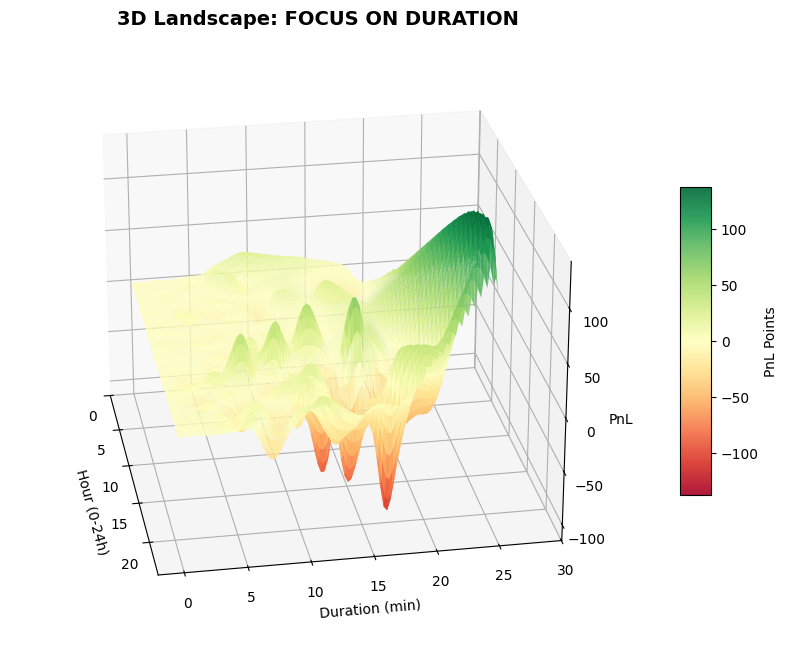

In [29]:
if 'results' in locals() and not results.empty:
    print("Generating 3D Analysis...")
    
    df_3d = results[results['Duration_min'] <= 28].copy()
    
    if len(df_3d) > 20:
        df_3d['Entry Time'] = pd.to_datetime(df_3d['Entry Time'])
        df_3d['Hour_Float'] = df_3d['Entry Time'].dt.hour + df_3d['Entry Time'].dt.minute / 60.0
        
        x = df_3d['Hour_Float']
        y = df_3d['Duration_min']
        z = df_3d['Points']

        # Create grid
        xi = np.linspace(0, 24, 100)
        yi = np.linspace(0, 28, 100)
        xi, yi = np.meshgrid(xi, yi)

        # Interpolation
        zi = griddata((x, y), z, (xi, yi), method='linear')

        # Gaussian smoothing while preserving NaNs
        mask_nan = np.isnan(zi)
        zi_filled = np.nan_to_num(zi, nan=0.0)
        zi_smooth = gaussian_filter(zi_filled, sigma=1.5)
        zi_smooth[mask_nan] = np.nan

         # Normalize colors (center at 0)
        valid_vals = zi_smooth[~np.isnan(zi_smooth)]
        if len(valid_vals) > 0:
            max_abs = np.max(np.abs(valid_vals))
            if max_abs == 0: max_abs = 1.0
            norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
        else:
            norm = None

        # --- View 1: Focus on Time ---
        fig1 = plt.figure(figsize=(14, 8))
        ax1 = fig1.add_subplot(111, projection='3d')
        surf1 = ax1.plot_surface(
            xi, yi, zi_smooth, cmap='RdYlGn', norm=norm, 
            antialiased=True, alpha=0.9, rstride=1, cstride=1, edgecolor='none'
        )
        ax1.set_title('3D Landscape: FOCUS ON TIME OF DAY', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Hour (0-24h)')
        ax1.set_ylabel('Duration (min)')
        ax1.set_zlabel('PnL')
        ax1.set_xlim(0, 24)
        ax1.view_init(elev=25, azim=-80)
        ax1.dist = 9
        fig1.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='PnL Points')
        plt.show()

        # --- View 2: Focus on Duration ---
        fig2 = plt.figure(figsize=(14, 8))
        ax2 = fig2.add_subplot(111, projection='3d')
        surf2 = ax2.plot_surface(
            xi, yi, zi_smooth, cmap='RdYlGn', norm=norm, 
            antialiased=True, alpha=0.9, rstride=1, cstride=1, edgecolor='none'
        )
        ax2.set_title('3D Landscape: FOCUS ON DURATION', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Hour (0-24h)')
        ax2.set_ylabel('Duration (min)')
        ax2.set_zlabel('PnL')
        ax2.set_xlim(0, 24)
        ax2.view_init(elev=25, azim=-10)
        ax2.dist = 9
        fig2.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='PnL Points')
        plt.show()

else:
        print("Too few trades (< 20) for 3D analysis.")

#### Top Trades Evaluation:

In [30]:
if 'results' in locals() and not results.empty:
    top_wins = results.nlargest(10, 'Points')
    top_losses = results.nsmallest(10, 'Points')
    
    print("\n=== TOP 10 WINNING TRADES ===")
    display(top_wins[['Entry Time', 'Exit Time', 'Type', 'Points', 'Duration_min', 'Reason']])
    
    print("\n=== TOP 10 LOSING TRADES ===")
    display(top_losses[['Entry Time', 'Exit Time', 'Type', 'Points', 'Duration_min', 'Reason']])



=== TOP 10 WINNING TRADES ===


,Entry Time,Exit Time,Type,Points,Duration_min,Reason
2463,2025-10-10 16:56:00+02:00,2025-10-10 17:03:00+02:00,SHORT,319.00,7.0,Divergence
8530,2025-11-06 16:25:00+01:00,2025-11-06 16:52:00+01:00,SHORT,180.00,27.0,Divergence
12554,2025-11-25 15:43:00+01:00,2025-11-25 15:50:00+01:00,SHORT,142.50,7.0,Divergence
6892,2025-10-30 14:44:00+01:00,2025-10-30 14:53:00+01:00,LONG,135.50,9.0,Divergence
4001,2025-10-17 15:48:00+02:00,2025-10-17 16:03:00+02:00,LONG,131.50,15.0,Divergence
10737,2025-11-17 15:30:00+01:00,2025-11-17 15:37:00+01:00,LONG,130.75,7.0,Divergence
2467,2025-10-10 17:15:00+02:00,2025-10-10 17:19:00+02:00,SHORT,121.75,4.0,Divergence
14252,2025-12-03 15:01:00+01:00,2025-12-03 15:05:00+01:00,SHORT,116.00,4.0,Divergence
10759,2025-11-17 17:18:00+01:00,2025-11-17 17:30:00+01:00,LONG,100.50,12.0,Divergence
8558,2025-11-06 19:01:00+01:00,2025-11-06 19:10:00+01:00,SHORT,100.00,9.0,Divergence



=== TOP 10 LOSING TRADES ===


,Entry Time,Exit Time,Type,Points,Duration_min,Reason
3422,2025-10-15 18:57:00+02:00,2025-10-15 19:14:00+02:00,LONG,-190.50,17.0,Divergence
11680,2025-11-20 18:31:00+01:00,2025-11-20 18:36:00+01:00,LONG,-143.25,5.0,Divergence
11049,2025-11-18 15:37:00+01:00,2025-11-18 15:50:00+01:00,LONG,-139.50,13.0,Divergence
11673,2025-11-20 17:34:00+01:00,2025-11-20 17:48:00+01:00,LONG,-127.00,14.0,Divergence
11417,2025-11-19 22:18:00+01:00,2025-11-19 22:25:00+01:00,SHORT,-126.75,7.0,Divergence
11870,2025-11-21 10:57:00+01:00,2025-11-21 11:05:00+01:00,LONG,-123.75,8.0,Divergence
12235,2025-11-24 15:29:00+01:00,2025-11-24 15:46:00+01:00,SHORT,-121.00,17.0,Divergence
5006,2025-10-22 18:33:00+02:00,2025-10-22 18:35:00+02:00,SHORT,-119.75,2.0,Divergence
11985,2025-11-21 19:47:00+01:00,2025-11-21 19:49:00+01:00,SHORT,-117.00,2.0,Divergence
2469,2025-10-10 17:28:00+02:00,2025-10-10 17:31:00+02:00,LONG,-116.25,3.0,Divergence


## 3.7 Baseline Strategy Evaluation

### **A. Market Regime Analysis**
- **Non-stationary BTC–NQ relationship:** Correlation varies across market regimes.
- **Event-Driven Synchronization:** Rolling correlations spike (>0.7) around **NY Market Open (15:30 CET)**, confirming high-volume events drive asset synchronization.
- **Golden Hours:** Hourly heatmap identifies **15:00–17:00 CET** as stable positive correlation windows, optimal for cross-asset signals.

### **B. Strategy Performance (Backtest)**
- **Profitability Drivers:** Alpha is mainly captured during high-correlation windows.  
- **Drawdown Periods:** Losses occur when correlation weakens, e.g., London lunch lull (12:00–14:00) and late NY session. 

### **C. Advanced Optimization Insights (3D Analysis)**
- **High-probability sessions:** Most profitable trades cluster in **NY session**, minor cluster at Asian session open (requires more data).  
- **Trade Duration:** Short trades (0–3 min) are mostly unprofitable; filtering these could reduce losses.

## 3.8 Motivation for Machine Learning Enhancement

The backtesting and microstructure analysis highlight opportunities for improving strategy performance using machine learning:

- **Time-Filtering Optimization:** ML models can dynamically identify high-probability trading windows (e.g., "golden hours") instead of using fixed hours.  
- **Feature-Based Signal Enhancement:** Incorporating additional features such as `Rolling_Corr_60m`, Bollinger Bands, volatility measures, or other microstructure indicators can allow ML algorithms to filter low-quality trades and improve predictive accuracy.  
- **Trade Quality Prediction:** ML can help predict which signals are likely to be profitable, reducing the frequency of ultra-short, unprofitable trades.  
- **Adaptive Strategy:** Machine learning enables the strategy to adjust to non-stationary market regimes, capturing evolving correlations between BTC and NQ.
